# Loan Application Data Analysis

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Loading the Dataset

The original dataset is loaded into `df` and preserved without modification. A copy of the dataset is created as `data`, which will be used for all cleaning, analysis, and exploratory data analysis.

In [82]:

df=pd.read_csv(r"C:\Users\ADMIN\Downloads\raw_data.csv")
data=df.copy()

## 2. Initial Data Assessment

Before cleaning the dataset, we first examine its overall size and structure.

In [83]:
data.shape

(981, 12)

## 3. Sample of the Dataset

A sample of the first 20 records is displayed to get a clearer view of the data and its current formatting.

In [84]:
data.head(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,m,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Uban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban
3,LP001035,m,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422.0,152.0,360.0,1.0,Urban
6,LP001055,Female,No,1,Not Graduate,No,2226,0.0,59.0,360.0,1.0,Semiurban
7,LP001056,m,Yes,2,Not Graduate,No,3881,0.0,147.0,360.0,0.0,Rurl
8,LP001059,Male,Yes,2,Graduate,NaN,13633,0.0,280.0,240.0,1.0,Urban
9,LP001067,Male,No,0,Not Graduate,No,2400,2400.0,123.0,360.0,1.0,Semiurban


## 4. Dataset Structure

We examine the column names and data types to identify the variables available and detect any formatting issues before cleaning.

In [85]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            981 non-null    str    
 1   Gender             957 non-null    str    
 2   Married            978 non-null    str    
 3   Dependents         956 non-null    str    
 4   Education          981 non-null    str    
 5   Self_Employed      926 non-null    str    
 6   ApplicantIncome    981 non-null    int64  
 7   CoapplicantIncome  981 non-null    float64
 8   LoanAmount         954 non-null    float64
 9   Loan_Amount_Term   961 non-null    float64
 10  Credit_History     902 non-null    float64
 11  Property_Area      981 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 92.1 KB


## 5. Missing Values

We check each column for missing values to identify fields that may require cleaning or appropriate treatment.

In [86]:
data.isnull().sum()

Loan_ID               0
Gender               24
Married               3
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
dtype: int64

## 6. Duplicate Records

We check for duplicate records to determine whether any observations have been repeated in the dataset.

In [87]:
data.duplicated().sum()

np.int64(0)

## 7. Categorical Value Consistency

We examine the unique values in categorical columns to identify inconsistent spellings, formats, or unexpected categories that may need standardization.

In [88]:
categorical_columns=data.select_dtypes(include=["str"]).columns
for column in categorical_columns:
    print(f"\n{column}:")
    print(data[column].value_counts(dropna=False))


Loan_ID:
Loan_ID
LP001015    1
LP001022    1
LP001031    1
LP001035    1
LP001051    1
           ..
LP002978    1
LP002979    1
LP002983    1
LP002984    1
LP002990    1
Name: count, Length: 981, dtype: int64

Gender:
Gender
Male      582
m         193
Female    137
f          45
NaN        24
Name: count, dtype: int64

Married:
Married
Yes    631
No     347
NaN      3
Name: count, dtype: int64

Dependents:
Dependents
0      545
1      160
2      160
3+      91
NaN     25
Name: count, dtype: int64

Education:
Education
Graduate        763
Not Graduate    218
Name: count, dtype: int64

Self_Employed:
Self_Employed
No     807
Yes    119
NaN     55
Name: count, dtype: int64

Property_Area:
Property_Area
Semiurban    280
Urban        274
Rural        232
Semiurbn      37
Uban          22
Urben         20
Rurl          18
Semurban      18
Urbun         16
Rurall        16
Semiurben     14
Rurel         14
Rual          10
Urbn          10
Name: count, dtype: int64


## 8. Numerical Data Assessment
We examine the numerical variables to identify unusual values and potential outliers that may require further investigation.

In [89]:
data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,981.000000,981.000000,954.000000,961.000000,902.000000
mean,5179.795107,1601.916330,142.511530,342.201873,0.835920
std,5695.104533,2718.772806,77.421743,65.100602,0.370553
min,0.000000,0.000000,9.000000,6.000000,0.000000
25%,2875.000000,0.000000,100.000000,360.000000,1.000000
50%,3800.000000,1110.000000,126.000000,360.000000,1.000000
75%,5516.000000,2365.000000,162.000000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


## 9. Loan Term Consistency

We examine the unique loan-term values to identify unusual or inconsistent terms that may require further investigation.

In [90]:
data["Loan_Amount_Term"].value_counts(dropna=False).sort_index()

Loan_Amount_Term
6.0        1
12.0       2
36.0       3
60.0       3
84.0       7
120.0      4
180.0     66
240.0      8
300.0     20
350.0      1
360.0    823
480.0     23
NaN       20
Name: count, dtype: int64

## 10. Zero-Value Assessment

We check numerical fields for zero values to determine whether they represent valid observations or potential data-quality issues.

In [91]:
(data[["ApplicantIncome","CoapplicantIncome","LoanAmount"]]==0).sum()

ApplicantIncome        2
CoapplicantIncome    429
LoanAmount             0
dtype: int64

## 11. Unusual Loan Term Values

We identify loan terms that occur infrequently to determine whether they require correction or further investigation.

In [92]:
data["Loan_Amount_Term"].value_counts().loc[lambda x:x<10]

Loan_Amount_Term
240.0    8
84.0     7
120.0    4
60.0     3
36.0     3
12.0     2
350.0    1
6.0      1
Name: count, dtype: int64

## 12. Data Quality Issues Identified

The initial assessment identified the following data-quality issues:

1. Inconsistent `Gender` values, with `m`/`Male` and `f`/`Female` representing the same categories. 
2. Missing values in `Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, and `Credit_History`.
3. Inconsistent `Property_Area` values caused by spelling variations such as `Uban`, `Urben`, `Rurl`, and `Semiurbn`.
4. Two records have an `ApplicantIncome` of `0`, requiring investigation.
5. `Loan_Amount_Term` contains an unusual `350`-month value that occurs only once.


## 13. Standardizing Gender Values

The `Gender` column contains inconsistent representations of the same categories. We standardize `m` to `Male` and `f` to `Female` while preserving the existing missing values.

In [93]:
data["Gender"]=data["Gender"].replace({"m":"Male","f":"Female"})

In [94]:
data["Gender"].value_counts(dropna=False)

Gender
Male      775
Female    182
NaN        24
Name: count, dtype: int64

## 14. Standardizing Property Area Values

The `Property_Area` column contains multiple spelling variations of the same three categories. These values are standardized to `Urban`, `Rural`, and `Semiurban`.

In [95]:
data["Property_Area"]=data["Property_Area"].replace({
    "Uban":"Urban",
    "Urben":"Urban",
    "Urbun":"Urban",
    "Urbn":"Urban",
    "Rurl":"Rural",
    "Rurel":"Rural",
    "Rurall":"Rural",
    "Rual":"Rural",
    "Semiurbn":"Semiurban",
    "Semiurben":"Semiurban",
    "Semurban":"Semiurban"
})

In [96]:
data["Property_Area"].value_counts(dropna=False)

Property_Area
Semiurban    349
Urban        342
Rural        290
Name: count, dtype: int64

## 15. Handling Missing Values

Missing values are present in several columns. We will handle them using appropriate replacements based on the type and meaning of each variable.

In [97]:
data.isnull().sum()

Loan_ID               0
Gender               24
Married               3
Dependents           25
Education             0
Self_Employed        55
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
Property_Area         0
dtype: int64

### 15.1 Identifying Missing String Data

We isolate the categorical variables to determine the extent of missing information before deciding how it should be handled.

In [98]:
string_columns=data.select_dtypes(include=["str"]).columns
data[string_columns].isnull().sum()

Loan_ID           0
Gender           24
Married           3
Dependents       25
Education         0
Self_Employed    55
Property_Area     0
dtype: int64

### 15.2 Handling Missing String Data

Missing values in categorical columns are replaced with `Unknown` to clearly indicate that the information was not provided in the original dataset.

In [99]:
data[string_columns]=data[string_columns].fillna("Unknown")

In [100]:
data[string_columns].isnull().sum()

Loan_ID          0
Gender           0
Married          0
Dependents       0
Education        0
Self_Employed    0
Property_Area    0
dtype: int64

### 15.3 Identifying Numerical Missing Data

We identify the numerical columns with missing values before deciding how they should be handled.

In [101]:
data.select_dtypes(include="number").isnull().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     20
Credit_History       79
dtype: int64

### 15.4 Assessing Numerical Missing Values

We examine the distributions of the numerical variables with missing values to determine suitable methods for handling them.

In [102]:
data[["LoanAmount","Loan_Amount_Term","Credit_History"]].describe()

,LoanAmount,Loan_Amount_Term,Credit_History
count,954.000000,961.000000,902.000000
mean,142.511530,342.201873,0.835920
std,77.421743,65.100602,0.370553
min,9.000000,6.000000,0.000000
25%,100.000000,360.000000,1.000000
50%,126.000000,360.000000,1.000000
75%,162.000000,360.000000,1.000000
max,700.000000,480.000000,1.000000


### 15.5 Handling Numerical Missing Data

Missing `LoanAmount` values are replaced with the median, while missing `Loan_Amount_Term` values are replaced with the most common loan term of 360 months.

In [103]:
data["LoanAmount"]=data["LoanAmount"].fillna(data["LoanAmount"].median())
data["Loan_Amount_Term"]=data["Loan_Amount_Term"].fillna(data["Loan_Amount_Term"].mode()[0])

In [104]:
data[["LoanAmount","Loan_Amount_Term"]].isnull().sum()

LoanAmount          0
Loan_Amount_Term    0
dtype: int64

### 15.6 Handling Missing Credit History

Missing `Credit_History` values are replaced with `Unknown` to distinguish unavailable information from the existing `0` and `1` categories.

In [105]:
data["Credit_History"]=data["Credit_History"].astype("string").fillna("Unknown")

In [106]:
data["Credit_History"].value_counts(dropna=False)

Credit_History
1.0        754
0.0        148
Unknown     79
Name: count, dtype: Int64

## 16. Investigating Zero Applicant Income

Two records contain an `ApplicantIncome` value of zero. These records are reviewed to determine whether the values represent valid observations or data-entry errors.

In [107]:
data[data["ApplicantIncome"]==0]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
25,LP001153,Male,No,0,Graduate,No,0,24000.0,148.0,360.0,0.0,Rural
116,LP001607,Female,No,0,Not Graduate,No,0,1760.0,180.0,360.0,1.0,Semiurban


## 17. Handling Zero Applicant Income

The two records with zero `ApplicantIncome` were reviewed alongside their corresponding `CoapplicantIncome`. Since both records contain coapplicant income, the zero applicant income values were retained as potentially valid observations.

## 18. Investigating Unusual Loan Term

One record contains a `Loan_Amount_Term` of 350 months, which is an uncommon value in the dataset. The record is reviewed to determine whether it should be corrected or retained.

In [108]:
data[data["Loan_Amount_Term"]==350]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
157,LP001867,Male,Yes,0,Graduate,No,4333,2291.0,133.0,350.0,1.0,Rural


## 19. Handling Unusual Loan Term

The record with a 350-month loan term was reviewed and contains other complete and plausible application information. Since there is insufficient evidence to classify the value as an error, it is retained in the dataset.

## 20. Confirming No Missing values

In [109]:
data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

## 21. Data is now clean

## 22. Exploratory Data Analysis

The cleaned dataset is explored to identify patterns, distributions, and relationships that can provide useful insights for the loan application use case.

### 22.1. Applicant Profile

We examine the distribution of key applicant characteristics to understand the composition of the loan applications.

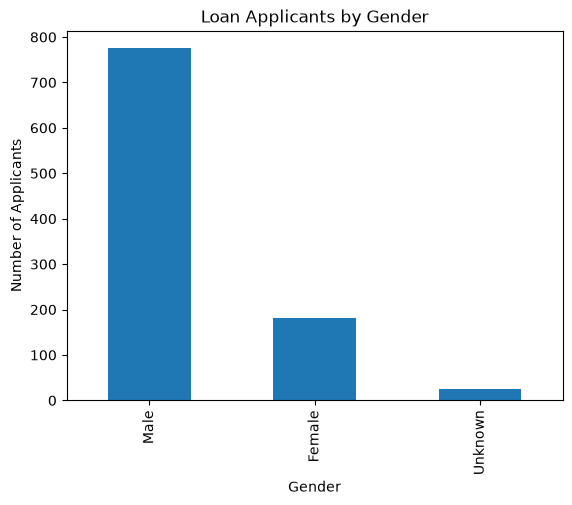

In [110]:
data["Gender"].value_counts().plot(kind="bar")
plt.title("Loan Applicants by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.show()

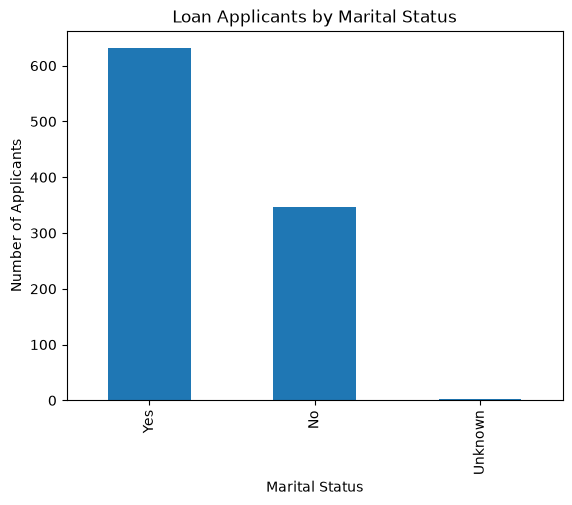

In [111]:
data["Married"].value_counts().plot(kind="bar")
plt.title("Loan Applicants by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")
plt.show()

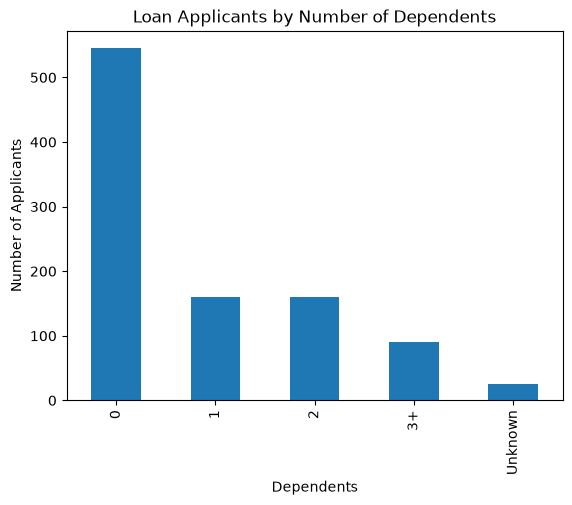

In [112]:
data["Dependents"].value_counts().plot(kind="bar")
plt.title("Loan Applicants by Number of Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Applicants")
plt.show()

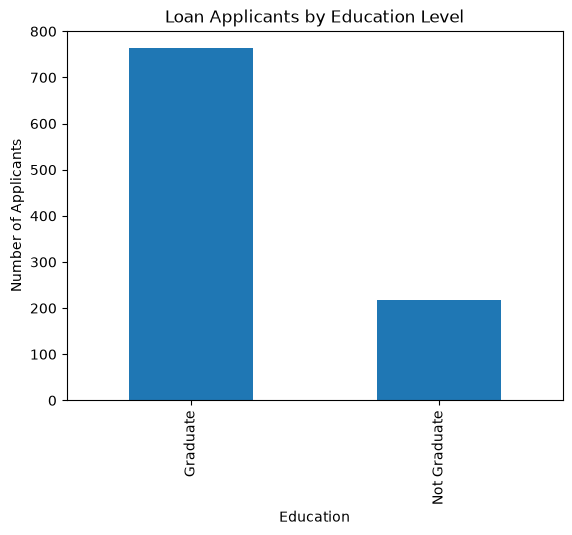

In [113]:
data["Education"].value_counts().plot(kind="bar")
plt.title("Loan Applicants by Education Level")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.show()

### 22.2 Income and Loan Analysis

The distribution of applicant income, coapplicant income, and loan amounts is examined to understand the financial characteristics of the loan applications.

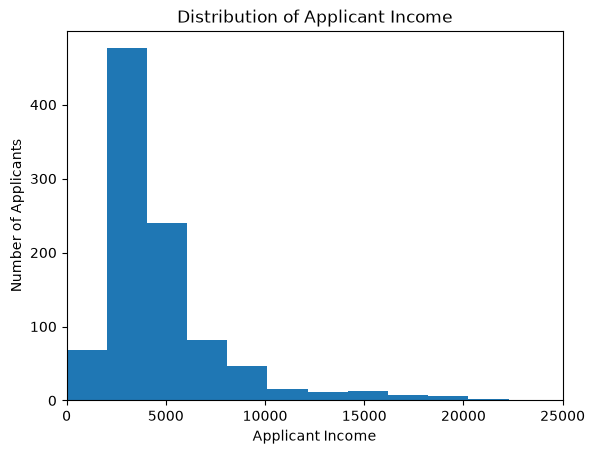

In [114]:
data["ApplicantIncome"].plot(kind="hist",bins=40,xlim=(0,25000))
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Number of Applicants")
plt.show()


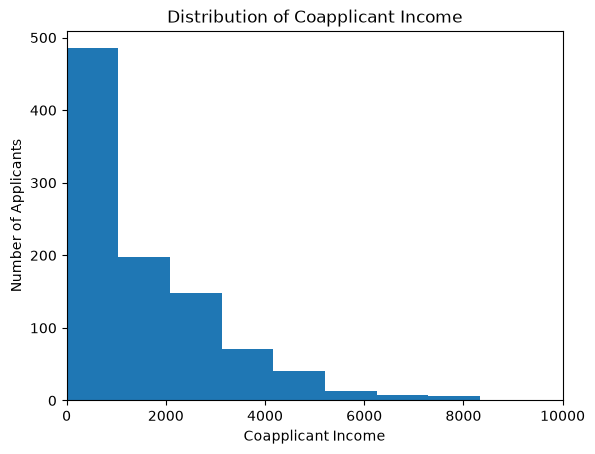

In [115]:
data["CoapplicantIncome"].plot(kind="hist",bins=40,xlim=(0,10000))
plt.title("Distribution of Coapplicant Income")
plt.xlabel("Coapplicant Income")
plt.ylabel("Number of Applicants")
plt.show()

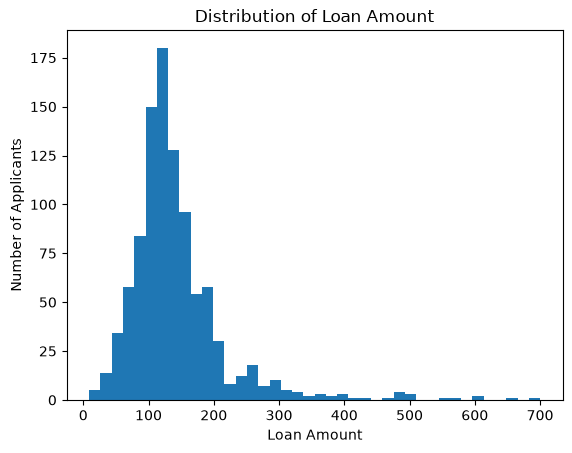

In [116]:
data["LoanAmount"].plot(kind="hist",bins=40)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applicants")
plt.show()

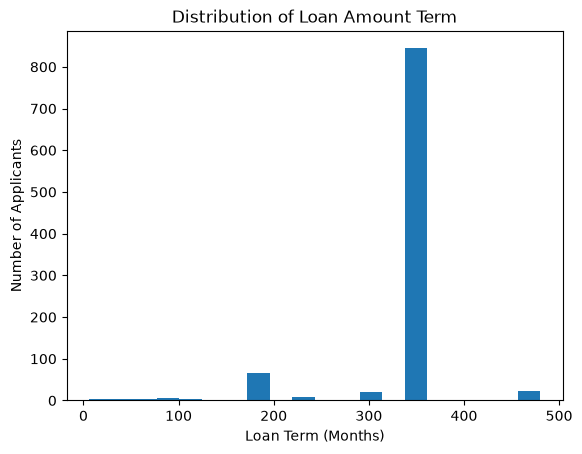

In [117]:
data["Loan_Amount_Term"].plot(kind="hist",bins=20)
plt.title("Distribution of Loan Amount Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Number of Applicants")
plt.show()

### 22.3 Credit History Analysis

The distribution of credit history is examined to understand the credit profile of the loan applicants.

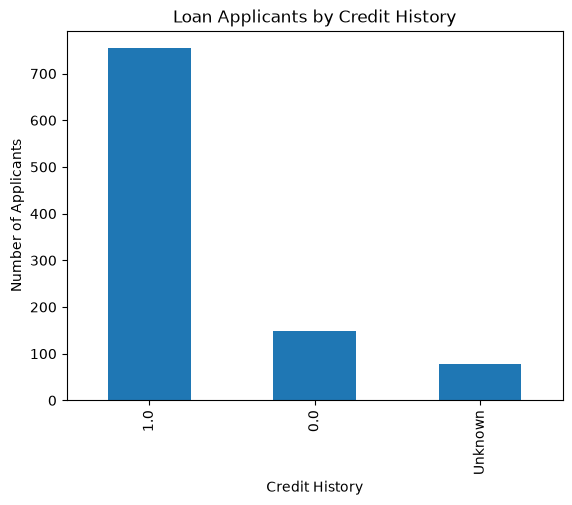

In [118]:
data["Credit_History"].value_counts().plot(kind="bar")
plt.title("Loan Applicants by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.show()

### 22.4 Relationship Analysis

Relationships between applicant characteristics and loan-related variables are examined to identify patterns that may be relevant to loan assessment.

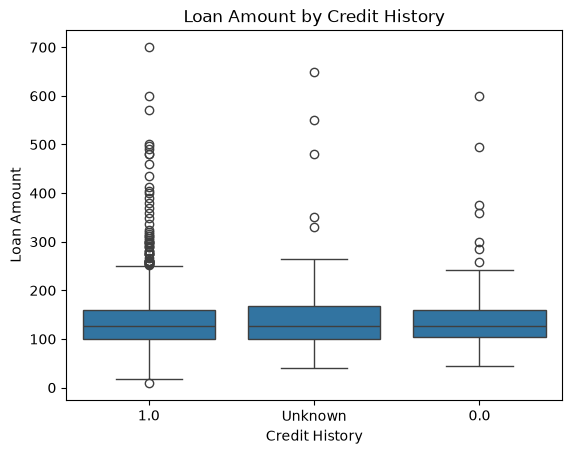

In [119]:
sns.boxplot(data=data,x="Credit_History",y="LoanAmount")
plt.title("Loan Amount by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Loan Amount")
plt.show()

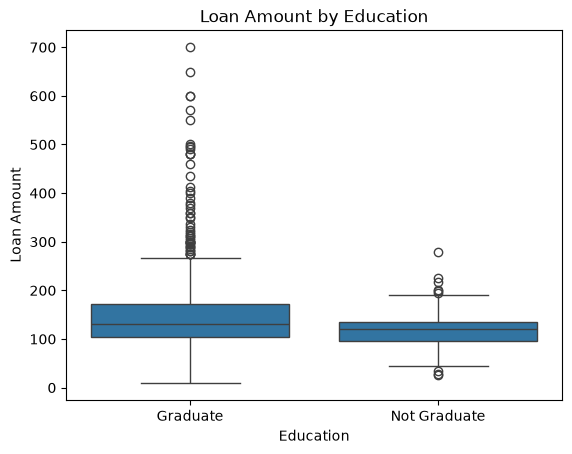

In [120]:
sns.boxplot(data=data,x="Education",y="LoanAmount")
plt.title("Loan Amount by Education")
plt.xlabel("Education")
plt.ylabel("Loan Amount")
plt.show()

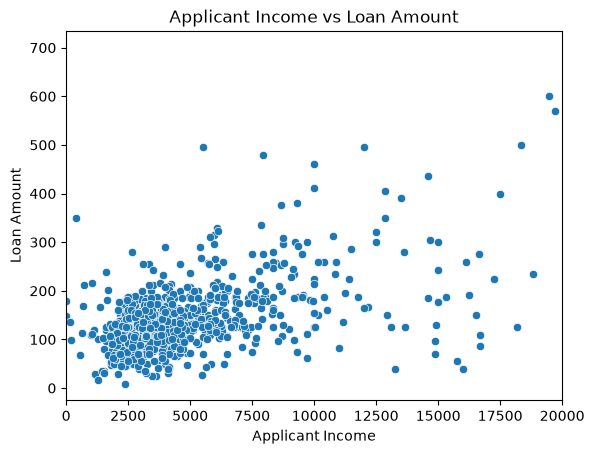

In [121]:
sns.scatterplot(data=data,x="ApplicantIncome",y="LoanAmount")
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.xlim(0,20000)
plt.show()

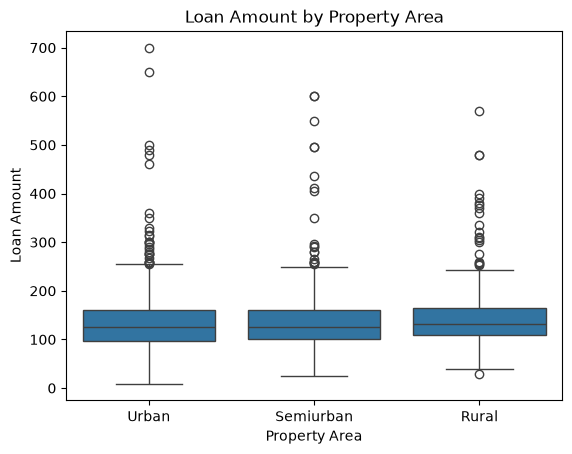

In [122]:
sns.boxplot(data=data,x="Property_Area",y="LoanAmount")
plt.title("Loan Amount by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Loan Amount")
plt.show()

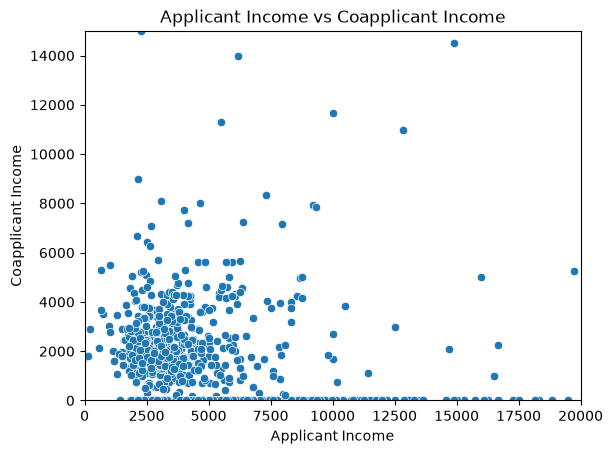

In [123]:
sns.scatterplot(data=data,x="ApplicantIncome",y="CoapplicantIncome")
plt.title("Applicant Income vs Coapplicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Coapplicant Income")
plt.xlim(0,20000)
plt.ylim(0,15000)
plt.show()

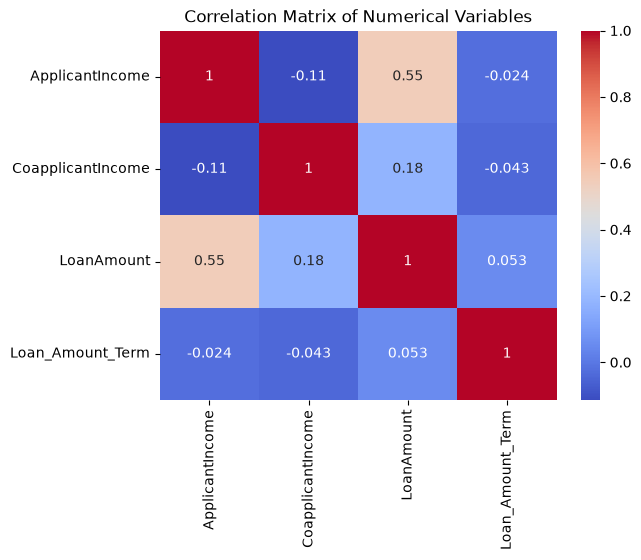

In [124]:
sns.heatmap(data.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### 22.5 Key EDA Findings

The exploratory analysis revealed several patterns in the loan application data:

1. The dataset contains more male applicants than female applicants.
2. Most applicants have no dependents, while applicants with three or more dependents form a smaller group.
3. Graduate applicants make up a larger proportion of the dataset than non-graduate applicants.
4. Applicant income and coapplicant income are unevenly distributed, with a small number of high-income observations.
5. Loan amounts are concentrated within a relatively smaller range, although some higher loan amounts are present.
6. Most loan applications have a loan term of 360 months.
7. Applicants with a positive credit history generally show different loan amount distributions from applicants with no credit history.
8. Loan amounts vary across education levels and property areas, indicating that applicant characteristics and location may be associated with the amount requested.
9. The correlation analysis shows the strength of relationships between the numerical financial variables.

### 22.6 Business Insights

The analysis suggests that loan applicants have different financial and demographic profiles, which can be useful when assessing loan applications.

1. Applicant income and coapplicant income provide information about the financial capacity of applicants.
2. Credit history is an important applicant characteristic that can be considered alongside income and requested loan amount.
3. Differences in loan amounts across education levels and property areas indicate that applicant characteristics may be useful when understanding loan demand.
4. The concentration of applications around a 360-month loan term suggests that long-term repayment periods are common within the dataset.
5. The presence of extreme income values indicates that financial variables should be considered carefully rather than relying only on averages.

### 22.7 Business Decision

The findings can support a more structured loan assessment process by encouraging the business to consider applicant income, coapplicant income, credit history, requested loan amount, and applicant characteristics together rather than relying on a single variable.

The business can use these patterns to better understand the financial profiles of applicants, identify applications that require additional review, and design loan products around common loan amounts and repayment terms observed in the data.

## 23. Exporting the Cleaned Dataset

The cleaned dataset is exported as a separate CSV file so that the original raw dataset remains unchanged and the cleaned data can be used for further analysis and reporting.

In [125]:
data.to_csv("cleaned_loan_data.csv",index=False)

In [126]:
data.shape

(981, 12)